# Daily Dip-and-Ride Swing Screener

**Open it, run all cells, read BUY NOW (and SELL / EXIT if you hold something).**

The idea: **buy dips, cut losers small, RIDE winners big.** We are *not* scalping 1-2%.
- **Buy a dip** - oversold (RSI-2 < 10) and/or stretched **>= 1.5 std-devs below the 20/21 band**
  (`z_band`). Get in cheap. **No 200-SMA, no 'must be above band'** (stocks retrace).
- **Cut losers easily** - a fixed **initial stop** (default 6%) below entry.
- **Ride winners (no take-profit)** - once in profit, a **trailing stop** rides the trend, so the
  **average win is large (~15-50%)** and the occasional monster runs. Winners ride, losers get cut.
- **Conviction = profit factor, not win rate.** Riding means a lower win rate but big asymmetric
  wins, so BUY NOW only shows names whose dip-and-ride history is a **proven money-maker**.

> **Research only, not financial advice.**

```bash
pip install -r requirements.txt
```

## 0. Why these rules - the ride-exit study

Backtested over 6 years on 110 popular tickers: dip entry, initial stop to cut losers, then ride
via a trailing stop (no quick take-profit). Killing the 1-2% take-profit is what unlocks big wins:

| Ride exit | Win % | **Avg win** | Avg loss | Expectancy | Max win | $100 -> |
|---|---|---|---|---|---|---|
| **chandelier 3xATR / 6% stop (default)** | ~40% | **+14.7%** | -6.3% | +2.14% | +316% | ~$313 |
| chandelier 5xATR / 8% stop | ~39% | **+25.4%** | -8.4% | +4.74% | +1455% | ~$272 |
| trail 25-30% off peak / 8% stop | ~31% | **+40-50%** | -10% | +6-8% | +481% | ~$240 |
| sma50 / 8% stop | ~58% | +7.7% | -6.5% | +1.70% | +1521% | ~$387 |

Small losses, big wins. `RIDE_MODE` (Section 1) lets you pick; Section 7 compares them live on $100.

## 1. Config - edit me

In [1]:
# --- make `wsb_screener` importable no matter where Jupyter was launched ---
import sys, os
from pathlib import Path
_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / "wsb_screener").is_dir():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        os.chdir(_p)
        break
else:
    raise RuntimeError("Could not find the 'wsb_screener' folder - open this notebook from inside "
                       "the trading-demo project folder.")
print("project dir:", os.getcwd())

UNIVERSE_SOURCE = "both"     # "popular" (mega caps + ETFs) | "wsb" | "both"
POPULAR_N   = 120
TOP_N       = 120
PERIOD      = "5y"
STOP_PCT    = 0.06           # initial stop = cut losers (try 0.05 / 0.06 / 0.08)
RIDE_MODE   = "chandelier"   # "chandelier" | "chandelier_wide" | "pct" | "sma50"
OUTDIR      = "results"

import wsb_screener.quant_core as qc
qc.STOP_PCT  = STOP_PCT       # push config into the model
qc.RIDE_MODE = RIDE_MODE
from wsb_screener import quant_screener as qscr
from wsb_screener.quant_report import build_markdown
from wsb_screener.data import get_universe, download_history
from wsb_screener.quant_core import portfolio_backtest, swing_backtest, live_signal, compute_stats
import importlib; importlib.reload(qscr)
import pandas as pd
pd.set_option("display.max_rows", 250, "display.width", 260, "display.max_columns", 60)

project dir: /projects/sandbox/trading-demo


## 2. Fetch the universe (most popular stocks + ETFs, plus WSB) + daily history

In [2]:
uni   = get_universe(source=UNIVERSE_SOURCE, top_n=TOP_N, popular_n=POPULAR_N)
metas = {d["ticker"]: d for d in uni}
print(f"Universe: {len(metas)} names ({UNIVERSE_SOURCE})")
print(", ".join(list(metas)[:30]), "...")
hist = download_history(list(metas), period=PERIOD, interval="1d")
print(f"\nDownloaded daily data for {len(hist)}/{len(metas)} tickers")

Universe: 199 names (both)
AAPL, MSFT, NVDA, AMZN, GOOGL, GOOG, META, TSLA, AVGO, ORCL, AMD, NFLX, ADBE, CRM, CSCO, QCOM, TXN, INTC, IBM, AMAT, MU, INTU, NOW, UBER, SHOP, PLTR, SMCI, ARM, PANW, SNOW ...


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: OS"}}}


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: DAY"}}}


$DAY: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")


$OS: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")



2 Failed downloads:


['DAY', 'OS']: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")



Downloaded daily data for 197/199 tickers


## 3. Run the model (dip -> profit-factor gate -> position-aware bucket)

In [3]:
df = qscr.run_screener(hist, metas)
signal_date = df["signal_date"].dropna().mode().iloc[0]
print("Latest daily bar:", signal_date)
df["group"].value_counts()

  ...screened 25/199


  ...screened 50/199


  ...screened 75/199


  ...screened 100/199


  ...screened 125/199


  ...screened 150/199


  ...screened 175/199


Latest daily bar: 2026-07-09


group
HOLDING (RIDE)    146
WATCH              35
SELL / EXIT         8
SKIPPED             4
BUY NOW             3
CLOSE TO BUY        3
Name: count, dtype: int64

## 4. BUY NOW - high-conviction dips firing today
Dips in names whose dip-and-ride history is a proven money-maker (**profit factor** + big **avg win**).
Buy at next open; cut small if wrong; ride if right. Columns show each name's own backtest.

In [4]:
buy_cols = ["group_rank","ticker","name","close","score","rsi2","z_band",
            "bt_profit_factor","bt_avg_win_%","bt_winrate_%","bt_max_win_%","exit_plan","band_read","note"]
df[df.group=="BUY NOW"][buy_cols]

,group_rank,ticker,name,close,score,rsi2,z_band,bt_profit_factor,bt_avg_win_%,bt_winrate_%,bt_max_win_%,exit_plan,band_read,note
0,1,AZZ,AZZ,137.49,64.4,4.2,-2.08,2.05,10.2,55.6,37.1,"cut at 6%, then ride (trail 3xATR)","-2.1 sigma below band - stretched, buy zone","dip buy (PF 2.0, avg win +10%): RSI-2 4 (overs..."
1,2,LUNR,Intuitive Machines,16.92,46.5,2.1,-1.37,1.61,29.1,34.0,109.4,"cut at 6%, then ride (trail 3xATR)",-1.4 sigma below band - pulling back toward band,"dip buy (PF 1.6, avg win +29%): RSI-2 2 (overs..."
2,3,COST,COST,913.29,54.5,9.9,-2.16,1.58,10.8,38.7,35.3,"cut at 6%, then ride (trail 3xATR)","-2.2 sigma below band - stretched, buy zone","dip buy (PF 1.6, avg win +11%): RSI-2 10 (over..."


## 5. CLOSE TO BUY - thinner/unproven edge, or sliding into the dip zone

In [5]:
near_cols = ["group_rank","ticker","name","close","score","rsi2","z_band","dist_band_%",
             "vol_surge","bt_profit_factor","bt_avg_win_%","band_read","note"]
df[df.group=="CLOSE TO BUY"][near_cols]

,group_rank,ticker,name,close,score,rsi2,z_band,dist_band_%,vol_surge,bt_profit_factor,bt_avg_win_%,band_read,note
157,1,LEVI,Levi Strauss,24.02,58.6,7.7,0.02,0.04,2.12,1.29,10.5,at the band,"dip fired (PF 1.3): RSI-2 8 (oversold), vol 2...."
158,2,LOW,LOW,213.43,56.1,16.0,-1.52,-2.82,0.30,1.15,8.5,"-1.5 sigma below band - stretched, buy zone",dip fired (PF 1.1): -1.5 sigma below band -> c...
159,3,PEP,PEP,137.31,45.1,10.8,-1.73,-3.54,1.15,1.15,5.3,"-1.7 sigma below band - stretched, buy zone",dip fired (PF 1.1): -1.7 sigma below band -> c...


## 6. SELL / EXIT (only when it matters) + HOLDING (riding)
- **SELL / EXIT** - a model position exited today: **stop** (loser cut small) or **trail** (trend broke, lock the ride).
- **HOLDING (RIDE)** - entered on a prior dip and still riding the trend.

In [6]:
sell_cols = ["group_rank","ticker","name","close","entry_price","pos_ret_%","exit_reason","z_band","note"]
hold_cols = ["group_rank","ticker","name","close","entry_price","pos_gain_%","bars_held","z_band","exit_plan","stop_%"]
from IPython.display import display
print("SELL / EXIT");    display(df[df.group=="SELL / EXIT"][sell_cols])
print("HOLDING (RIDE)"); display(df[df.group=="HOLDING (RIDE)"][hold_cols].head(20))

SELL / EXIT


,group_rank,ticker,name,close,entry_price,pos_ret_%,exit_reason,z_band,note
3,1,KORU,Direxion Shares ETF Trust - Direxion Daily Sou...,567.51,625.63,-23.08,stop,-1.01,SELL: 6% stop hit (-23.1%) - loser cut; re-ent...
4,2,MU,MU,1007.92,1007.00,-10.36,stop,-0.26,SELL: 6% stop hit (-10.4%) - loser cut; re-ent...
5,3,RMBS,Rambus,115.58,115.81,-9.55,stop,-0.85,SELL: 6% stop hit (-9.6%) - loser cut; re-ente...
6,4,WDC,Western Digital,581.58,567.00,-7.23,stop,-0.31,SELL: 6% stop hit (-7.2%) - loser cut; re-ente...
7,5,MP,MP Materials,51.94,53.55,-5.70,trail,-1.32,"SELL: trailing stop hit (-5.7%) - trend broke,..."
8,6,WD,Walker & Dunlop,50.34,47.78,3.67,trail,-1.18,"SELL: trailing stop hit (+3.7%) - trend broke,..."
9,7,CAT,CAT,942.48,663.96,41.20,trail,-0.46,SELL: trailing stop hit (+41.2%) - trend broke...
10,8,SNDK,Sandisk,1900.73,588.01,170.71,trail,-0.11,SELL: trailing stop hit (+170.7%) - trend brok...


HOLDING (RIDE)


,group_rank,ticker,name,close,entry_price,pos_gain_%,bars_held,z_band,exit_plan,stop_%
11,1,AMD,AMD,545.56,197.13,176.75,104.0,0.82,"cut at 6%, then ride (trail 3xATR)",6.0
12,2,ASML,ASML,1810.98,1281.99,41.26,84.0,-0.08,"cut at 6%, then ride (trail 3xATR)",6.0
13,3,GO,Grocery Outlet,10.27,7.32,40.37,35.0,1.41,"cut at 6%, then ride (trail 3xATR)",6.0
14,4,LLY,LLY,1212.20,870.40,39.27,49.0,1.00,"cut at 6%, then ride (trail 3xATR)",6.0
15,5,RDDT,Reddit,198.64,143.49,38.43,30.0,1.32,"cut at 6%, then ride (trail 3xATR)",6.0
16,6,TSM,TSMC,438.80,324.07,35.40,70.0,-0.02,"cut at 6%, then ride (trail 3xATR)",6.0
17,7,BB,BlackBerry,11.39,8.42,35.21,12.0,0.69,"cut at 6%, then ride (trail 3xATR)",6.0
18,8,BULL,Webull,7.26,5.41,34.16,19.0,1.22,"cut at 6%, then ride (trail 3xATR)",6.0
19,9,DAL,Delta Air Lines,88.62,66.52,33.22,48.0,0.24,"cut at 6%, then ride (trail 3xATR)",6.0
20,10,GE,GE,359.79,283.04,27.12,35.0,0.16,"cut at 6%, then ride (trail 3xATR)",6.0


## 7. Give it $100 - portfolio backtest + ride-mode comparison
Trades the strategy across the whole universe with **$100** (1/8 of equity per trade, max 8
positions). Compares the ride exits so you can see the win-rate vs avg-win tradeoff, then plots
the equity curve for your chosen `RIDE_MODE`.

$100 portfolio - ride-mode comparison (initial stop = 6%):


,ride_mode,final_$,return_%,CAGR_%,maxDD_%,trades,win_%,avg_win_%
0,chandelier,238.85,138.8,20.5,-33.8,398,37.2,17.7
1,chandelier_wide,174.25,74.2,12.7,-25.8,213,30.5,27.3
2,pct,177.56,77.6,13.2,-39.2,176,19.3,54.2
3,sma50,149.93,49.9,9.0,-30.2,3115,47.2,2.9



Your config (RIDE_MODE=chandelier, stop=6%): $100 -> $238.85 (+139%, CAGR 20.5%/yr, maxDD -33.8%, 398 trades, 37.2% win, avg win +17.7%)


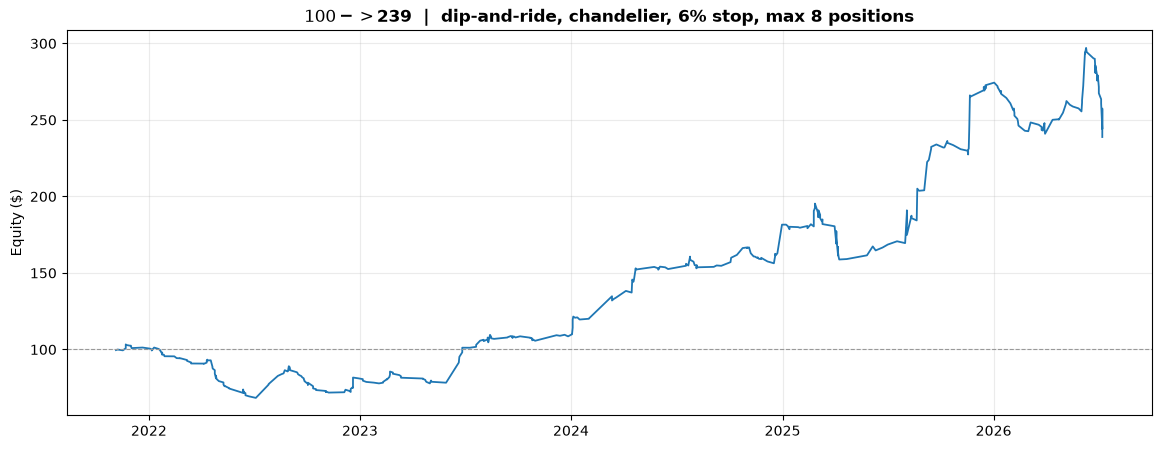

In [7]:
rows = []
for rm in ("chandelier", "chandelier_wide", "pct", "sma50"):
    p = portfolio_backtest(hist, start_cash=100.0, max_positions=8, stop_pct=STOP_PCT, ride_mode=rm)
    rows.append({"ride_mode": rm, "final_$": p["final_$"], "return_%": p["return_%"],
                 "CAGR_%": p["CAGR_%"], "maxDD_%": p["max_drawdown_%"], "trades": p["trades"],
                 "win_%": p["win_rate_%"], "avg_win_%": p["avg_win_%"]})
print("$100 portfolio - ride-mode comparison (initial stop = {:.0%}):".format(STOP_PCT))
display(pd.DataFrame(rows))

port = portfolio_backtest(hist, start_cash=100.0, max_positions=8, stop_pct=STOP_PCT, ride_mode=RIDE_MODE)
print(f"\nYour config (RIDE_MODE={RIDE_MODE}, stop={STOP_PCT:.0%}): $100 -> ${port['final_$']:.2f} "
      f"({port['return_%']:+.0f}%, CAGR {port['CAGR_%']}%/yr, maxDD {port['max_drawdown_%']}%, "
      f"{port['trades']} trades, {port['win_rate_%']}% win, avg win +{port['avg_win_%']}%)")

%matplotlib inline
import matplotlib.pyplot as plt
eq = port["equity_curve"]
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(eq["date"], eq["equity"], color="#1f77b4", lw=1.3); ax.axhline(100, color="#999", ls="--", lw=0.8)
ax.set_title(f"$100 -> ${port['final_$']:.0f}  |  dip-and-ride, {RIDE_MODE}, {STOP_PCT:.0%} stop, max 8 positions", weight="bold")
ax.set_ylabel("Equity ($)"); ax.grid(alpha=0.25); plt.show()

## 8. Save the scan (CSV + Markdown report)

In [8]:
os.makedirs(OUTDIR, exist_ok=True)
df.to_csv(f"{OUTDIR}/wsb_quant_screen.csv", index=False)
with open(f"{OUTDIR}/wsb_quant_report.md", "w") as f:
    f.write(build_markdown(df, len(metas), signal_date, portfolio=port))
print("wrote", f"{OUTDIR}/wsb_quant_screen.csv", "and", f"{OUTDIR}/wsb_quant_report.md")

wrote results/wsb_quant_screen.csv and results/wsb_quant_report.md


## 9. Drill into ANY ticker (not just the universe)
Type any market symbol - it downloads on the fly, shows price + band + dip-buy/exit markers, an
RSI-2 panel, and this ticker's own dip-and-ride backtest + $100 result.

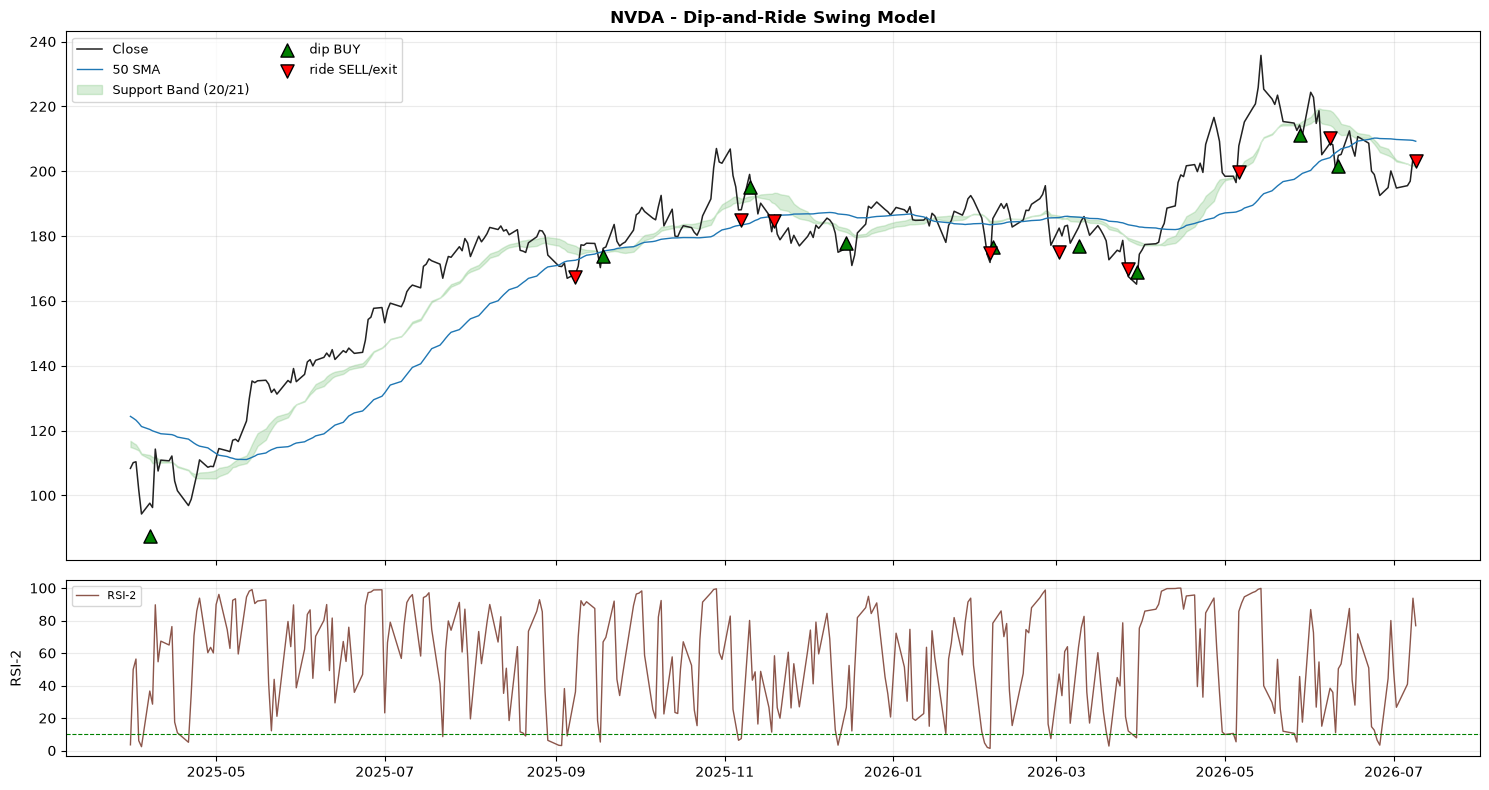

NVDA: score=13.0 | RSI-2=76.8 | z_band=0.24 (at the band) | plan: cut at 6%, then ride (trail 3xATR)
this ticker's dip-and-ride backtest: {'Total Trades': 39, 'Win Rate %': np.float64(33.3), 'Total P&L $': np.float64(3702.78), 'Avg Win %': np.float64(41.6), 'Avg Loss %': np.float64(-6.6), 'Max Win %': np.float64(192.8), 'Profit Factor': np.float64(3.16), 'Expectancy %': np.float64(9.49), 'Avg Bars Held': np.float64(24.1)}
$100 in ONLY NVDA: -> $766.65 (+667%, 38 trades, avg win +45.1%)


In [9]:
TICKER = "NVDA"   # <- ANY market ticker (NVDA, SPY, BTC-USD, TSM, JPM, PLTR ...)

h = download_history([TICKER], period=PERIOD, interval="1d")
data = h.get(TICKER) if h else None
if data is None or len(data) < 120:
    print(f"No / not enough data for {TICKER!r} - try another symbol.")
else:
    d, t = swing_backtest(data, stop_pct=STOP_PCT, ride_mode=RIDE_MODE)
    sig = live_signal(data); view = d.tail(320)
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(15,8), sharex=True, gridspec_kw={"height_ratios":[3,1]})
    ax.plot(view.Date, view.Close, color="#222", lw=1.1, label="Close")
    ax.plot(view.Date, view.SMA50, color="#1f77b4", lw=1.0, label="50 SMA")
    ax.fill_between(view.Date, view.band_bot, view.band_top, color="#2ca02c", alpha=0.18, label="Support Band (20/21)")
    tv = t[t.entry_date >= view.Date.iloc[0]] if not t.empty else t
    if not tv.empty:
        ax.scatter(tv.entry_date, tv.entry_price, marker="^", s=90, color="green", edgecolor="k", zorder=5, label="dip BUY")
        ax.scatter(tv.exit_date,  tv.exit_price,  marker="v", s=90, color="red",   edgecolor="k", zorder=5, label="ride SELL/exit")
    ax.set_title(f"{TICKER} - Dip-and-Ride Swing Model", weight="bold"); ax.legend(loc="upper left", ncol=2, fontsize=9); ax.grid(alpha=0.25)
    ax2.plot(view.Date, view.RSI2, color="#8c564b", lw=1.0, label="RSI-2"); ax2.axhline(10, color="green", ls="--", lw=0.8)
    ax2.set_ylabel("RSI-2"); ax2.grid(alpha=0.25); ax2.legend(loc="upper left", fontsize=8)
    plt.tight_layout(); plt.show()
    print(f"{TICKER}: score={sig['score']} | RSI-2={sig['rsi2']} | z_band={sig['z_band']} ({sig['band_read']}) | plan: {sig['exit_plan']}")
    print("this ticker's dip-and-ride backtest:", compute_stats(t))
    single = portfolio_backtest({TICKER: data}, start_cash=100.0, max_positions=1, stop_pct=STOP_PCT, ride_mode=RIDE_MODE)
    print(f"$100 in ONLY {TICKER}: -> ${single['final_$']:.2f} ({single['return_%']:+.0f}%, {single['trades']} trades, avg win +{single['avg_win_%']}%)")